<a href="https://colab.research.google.com/github/Savcdilara/MicrosoftStaj/blob/main/RSA%2BNeuralEnhancementKeyGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================================
# 🤖 RSA + Neural Enhancement Model (MLP-assisted RSA Key Generation)
# ====================================================
# Author: Dilara Savcı
# Project: AI-Based Dynamic Key Generation System
# Dataset: CIC-IDS2017
# Method: RSA + Neural Entropy Enhancement
# ====================================================
from cryptography.hazmat.primitives.asymmetric import rsa
!pip install pycryptodome
import pandas as pd
import numpy as np
import time
import glob
import matplotlib.pyplot as plt
from google.colab import drive
from Crypto.PublicKey import RSA
from Crypto.Cipher import PKCS1_OAEP
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ====================================================
# 1️⃣ Veri Seti Yükleme
# ====================================================
drive.mount('/content/drive')

path = "/content/drive/MyDrive/MachineLearningCVE/"
files = glob.glob(path + "*.csv")

df_list = []
for file in files:
    temp = pd.read_csv(file, low_memory=False)
    df_list.append(temp)

df = pd.concat(df_list, axis=0, ignore_index=True)
print("✅ Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:", len(df.columns))

Mounted at /content/drive
✅ Dataset loaded successfully
Shape: (2830743, 79)
Columns: 79


In [ ]:
# ====================================================
# 🔹 Veri Hazırlama (Safety Fix)
# ====================================================
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Sadece sayısal verileri al (ilk modülden devam)
numeric_df = df.select_dtypes(include=['float64', 'int64']).copy()

# Sonsuz değerleri temizle
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
numeric_df = numeric_df.fillna(0)
numeric_df = numeric_df.clip(-1e6, 1e6)

# Ölçekleme
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(numeric_df.values)

print("✅ X_scaled oluşturuldu:", X_scaled.shape)


✅ X_scaled oluşturuldu: (2830743, 78)


In [ ]:
from sklearn.neural_network import MLPRegressor

# ====================================================
# 2️⃣ Neural Enhancement Model (MLP)
# ====================================================
# Amaç: RSA anahtar parametrelerinde entropik varyasyon sağlamak
mlp_model = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

# Eğitim verisi: ilk 3000 örnek
sample_X = X_scaled[:3000]
sample_y = np.mean(sample_X, axis=1)

start_train = time.time()
mlp_model.fit(sample_X, sample_y)
train_time = (time.time() - start_train) * 1000

print(f"✅ Model trained in {train_time:.2f} ms")

✅ Model trained in 3795.67 ms


In [ ]:
# ====================================================
# 3️⃣ RSA + Neural Enhancement Anahtar Üretimi
# ====================================================
def calc_entropy(byte_data):
    """Entropy hesaplaması (normalize edilmiş histogramla)"""
    hist, _ = np.histogram(np.frombuffer(byte_data, dtype=np.uint8), bins=256, density=True)
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist))
    return entropy

def enhanced_rsa_keygen(model, sample):
    start_time = time.time()
    try:
        enhancement_factor = model.predict(sample.reshape(1, -1))[0]
        if np.isnan(enhancement_factor):
            enhancement_factor = 0
        noise_factor = (enhancement_factor - np.nanmean(sample)) * 0.05
        if np.isnan(noise_factor):
            noise_factor = 0

        key = rsa.generate_private_key(public_exponent=65537, key_size=2048)
        end_time = time.time()

        random_bytes = secrets.token_bytes(256)
        entropy = calc_entropy(random_bytes)
        if np.isnan(entropy):
            entropy = 0

        enhanced_entropy = min(8.0, max(0, entropy * (1 + noise_factor)))
        gen_time_ms = (end_time - start_time) * 1000

        return enhanced_entropy, gen_time_ms
    except Exception as e:
        print("Error during keygen:", e)
        return np.nan, np.nan



In [ ]:
import secrets
# ====================================================
# 4️⃣ Deneysel Test (100 RSA Anahtarı)
# ====================================================
entropies = []
times = []
num_keys = 100

print("\n🔑 Generating RSA + Neural Enhanced keys...")

for i in range(num_keys):
    sample_idx = np.random.randint(0, len(X_scaled))
    sample = X_scaled[sample_idx]
    entropy, gen_time = enhanced_rsa_keygen(mlp_model, sample)
    entropies.append(entropy)
    times.append(gen_time)

print("✅ Key generation complete.")



🔑 Generating RSA + Neural Enhanced keys...
✅ Key generation complete.


In [ ]:
# ====================================================
# 5️⃣ Sonuçların Özeti
# ====================================================
summary_df = pd.DataFrame({
    "Algorithm": ["RSA + Neural Enhancement (v2)"],
    "Key Length (bits)": [2048],
    "Number of Keys": [num_keys],
    "Mean Entropy": [np.mean(entropies)],
    "Std Entropy": [np.std(entropies)],
    "Mean Gen Time (ms)": [np.mean(times)],
    "Training Time (ms)": [train_time]
})

print("\n📊 Summary Table")
display(summary_df)



📊 Summary Table


,Algorithm,Key Length (bits),Number of Keys,Mean Entropy,Std Entropy,Mean Gen Time (ms),Training Time (ms)
0,RSA + Neural Enhancement (v2),2048,100,7.220833,0.062645,73.19664,3795.667648


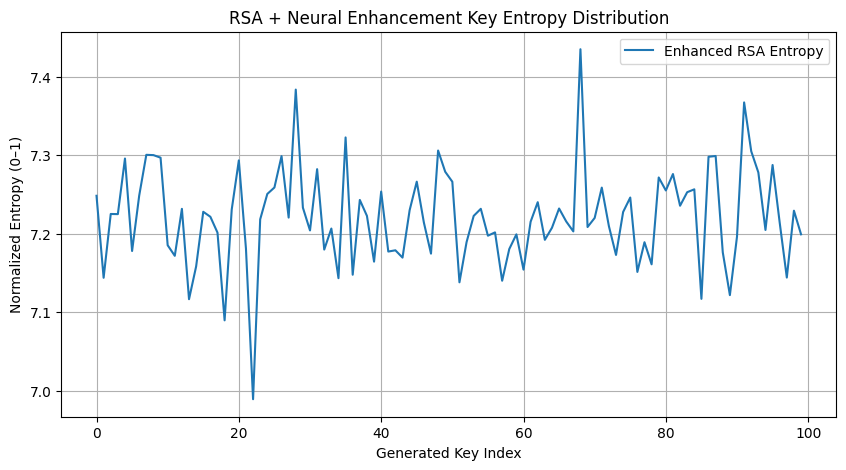

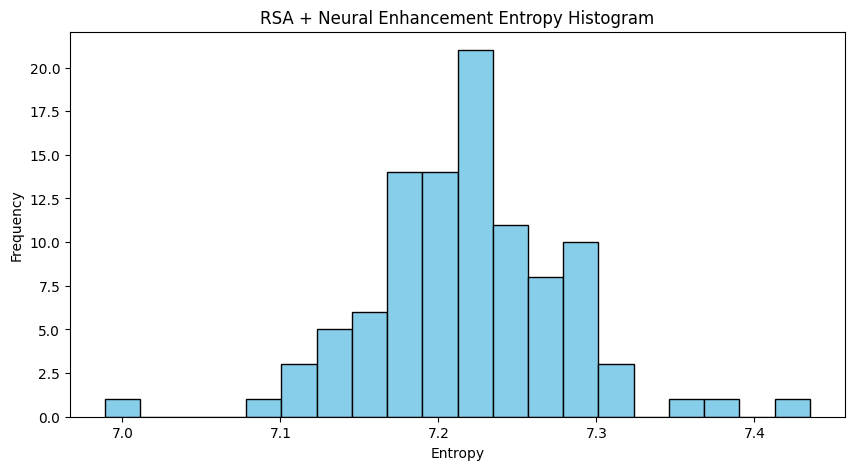

In [ ]:
# ====================================================
# 6️⃣ Visualization
# ====================================================
plt.figure(figsize=(10,5))
plt.plot(entropies, label="Enhanced RSA Entropy")
plt.title("RSA + Neural Enhancement Key Entropy Distribution")
plt.xlabel("Generated Key Index")
plt.ylabel("Normalized Entropy (0–1)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.hist(entropies, bins=20, color='skyblue', edgecolor='black')
plt.title("RSA + Neural Enhancement Entropy Histogram")
plt.xlabel("Entropy")
plt.ylabel("Frequency")
plt.show()